# Customer Segmentation using K-Means Clustering

**Dataset:** Mall Customers (200 customers) &nbsp;|&nbsp; **Tools:** Python, Pandas, Matplotlib, Scikit-learn

**Objective:** Group mall customers into meaningful segments using **Annual Income** and **Spending Score**, then describe each segment and suggest how a retailer could act on it.

**Workflow:** inspect data → prepare and scale features → explore → K-Means (elbow method) → analyse clusters → DBSCAN comparison → business insights.

In [1]:
# ---- Setup ----
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

RANDOM_STATE = 42          # makes K-Means results reproducible
DATA_PATH = "Mall_Customers.csv"
FIG_DIR = "figures"        # every plot is also saved here as a PNG
os.makedirs(FIG_DIR, exist_ok=True)

INCOME = "Annual Income (k$)"
SCORE = "Spending Score (1-100)"

## 1. Data Loading and Initial Inspection

In [2]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

print("First 5 rows:")
print(df.head())

print("\nShape (rows, columns):", df.shape)

print("\nColumn names and data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())
print("Duplicate CustomerIDs:", df["CustomerID"].duplicated().sum())

print("\nDescriptive statistics:")
print(df.describe().round(2))

print("\nGender counts:")
print(df["Gender"].value_counts())

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape (rows, columns): (200, 5)

Column names and data types:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Number of duplicate rows: 0
Duplicate CustomerIDs: 0

Descriptive statistics:
       CustomerID     Age  Annual Income (k$)  Spending Score (

**Observations**

- The dataset has 200 customers and 5 columns, with no missing values and no duplicate rows.
- `CustomerID` is only an identifier, so it carries no information for segmentation.
- Annual income ranges from 15k$ to 137k$ and spending score covers almost the full 1–100 scale. Both have a mean/median near the middle of their ranges and very similar standard deviations (about 26).

## 2. Data Preparation

### Feature selection
We cluster on **Annual Income** and **Spending Score** because together they describe a customer's *purchasing power* and their *actual buying behaviour*. Income shows how much a customer could spend, while the spending score shows how much they do spend. Combining the two separates customers who look similar on one measure but behave very differently on the other (for example, a high earner who rarely shops versus a modest earner who shops constantly). It also gives a 2-D problem that is easy to plot and explain.

`Age` and `Gender` are kept aside and used later only to *describe* the segments, not to build them. `CustomerID` is ignored.

Annual Income (k$): acceptable range [-13.2, 132.8] -> 2 outlier(s)
 CustomerID  Annual Income (k$)  Spending Score (1-100)
        199                 137                      18
        200                 137                      83
Spending Score (1-100): acceptable range [-22.6, 130.4] -> 0 outlier(s)


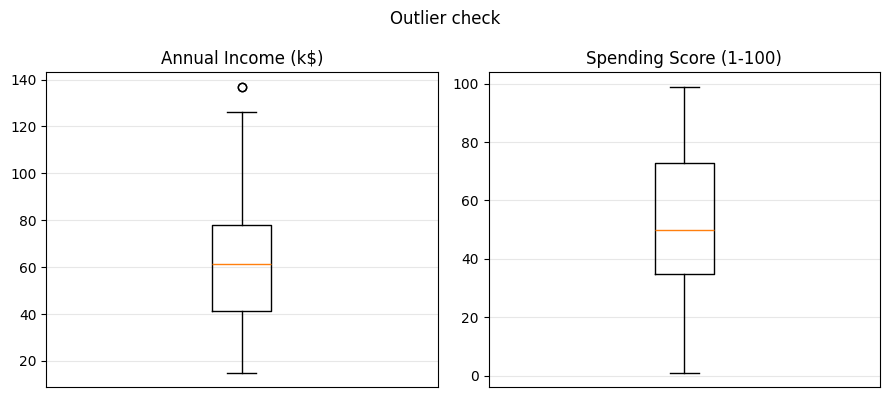

In [3]:
# Select the two clustering features
X = df[[INCOME, SCORE]]

# Check for outliers with the IQR rule (values beyond 1.5 * IQR from the quartiles)
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper

for col in [INCOME, SCORE]:
    outliers, lower, upper = iqr_outliers(df[col])
    print(f"{col}: acceptable range [{lower:.1f}, {upper:.1f}] -> {len(outliers)} outlier(s)")
    if len(outliers) > 0:
        print(df.loc[outliers.index, ["CustomerID", INCOME, SCORE]].to_string(index=False))

# Box plots for a visual check
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].boxplot(df[INCOME], vert=True)
axes[0].set_title("Annual Income (k$)")
axes[1].boxplot(df[SCORE], vert=True)
axes[1].set_title("Spending Score (1-100)")
for ax in axes:
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Outlier check")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_outlier_boxplots.png", dpi=150)
plt.show()

**Outlier decision:** only Annual Income has flagged values: two customers (IDs 199 and 200) at 137k$, just above the IQR upper limit. Spending Score has none. These are plausible high-income customers, not data errors, and their spending scores differ (18 and 83), so they are **kept**. Removing them would delete real high-value customers, which is exactly the group a business cares about.

### Feature scaling
K-Means (and DBSCAN) group points by **Euclidean distance**. If one feature had a much larger numeric range or variance, it would dominate the distance and the clusters would mostly reflect that feature. `StandardScaler` rewrites each feature to mean 0 and standard deviation 1 so every feature contributes equally. In this dataset the two features already have similar spreads, so scaling changes the results only modestly, but it is still the correct habit and it matters for DBSCAN, where `eps` is a distance in the scaled space.

In [4]:
# Standardise the features (mean = 0, std = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature means:", X_scaled.mean(axis=0).round(3))
print("Scaled feature std  :", X_scaled.std(axis=0).round(3))

Scaled feature means: [-0. -0.]
Scaled feature std  : [1. 1.]


## 3. Exploratory Data Analysis

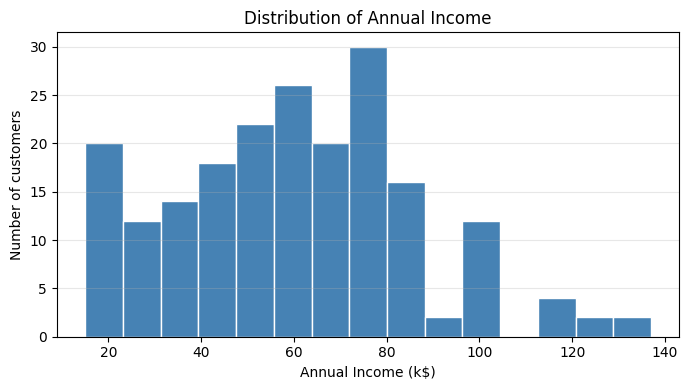

In [5]:
# Distribution of Annual Income
plt.figure(figsize=(7, 4))
plt.hist(df[INCOME], bins=15, color="steelblue", edgecolor="white")
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_income_distribution.png", dpi=150)
plt.show()

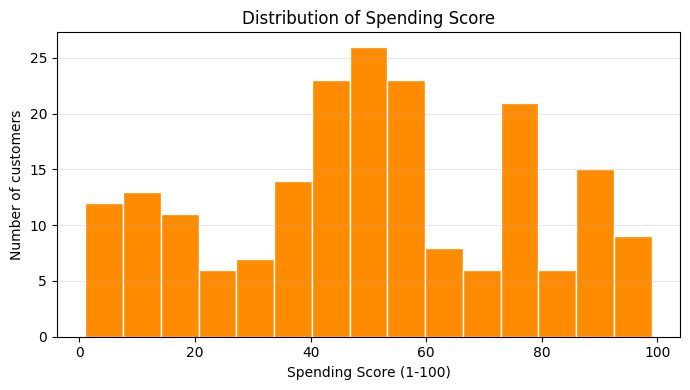

In [6]:
# Distribution of Spending Score
plt.figure(figsize=(7, 4))
plt.hist(df[SCORE], bins=15, color="darkorange", edgecolor="white")
plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_spending_score_distribution.png", dpi=150)
plt.show()

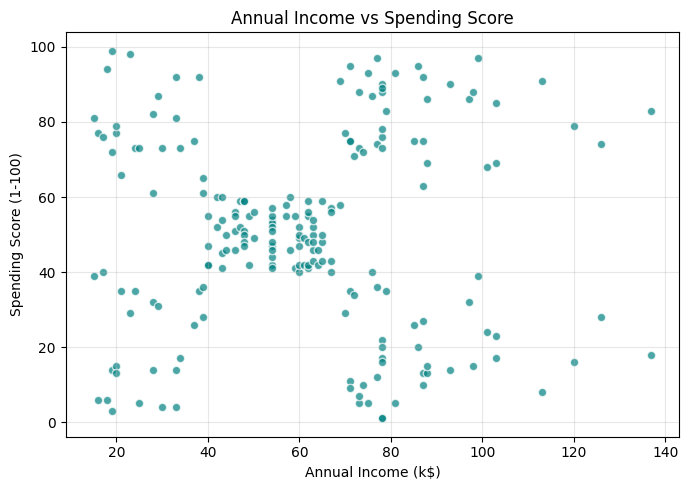

In [7]:
# Annual Income vs Spending Score
plt.figure(figsize=(7, 5))
plt.scatter(df[INCOME], df[SCORE], color="teal", alpha=0.7, edgecolor="white")
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_income_vs_score_scatter.png", dpi=150)
plt.show()

**Visible patterns**

- **Income** is roughly bell-shaped with most customers between about 40k$ and 80k$, and a thin tail up to 137k$.
- **Spending score** is spread widely across the scale, without one dominant peak.
- The **scatter plot does not show a simple linear trend** (income does not predict spending). Instead, it shows a dense central mass at middle income and middle score, plus separated groups toward the corners of the plot: low income with both low and high scores, and high income with both low and high scores. That suggests around five natural groups, which we now test with K-Means rather than assume.

## 4. K-Means Clustering: Choosing K with the Elbow Method

We fit K-Means for K = 2 to 10 and record the **inertia** (within-cluster sum of squared distances to the centroid). Inertia always falls as K grows, so we look for the *elbow*: the K after which extra clusters give only small improvements.

To avoid picking the elbow by eye alone, the code measures the elbow numerically: it finds the point on the inertia curve that is farthest from the straight line joining the first and last points. As a cross-check we also compute the **silhouette score** (higher means better separated clusters).

In [8]:
k_values = range(2, 11)
rows = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    rows.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_scaled, labels),
    })

k_results = pd.DataFrame(rows)
# Percentage drop in inertia compared with the previous K
k_results["Drop vs K-1 (%)"] = -k_results["Inertia"].pct_change() * 100
print(k_results.round(3).to_string(index=False))

 K  Inertia  Silhouette  Drop vs K-1 (%)
 2  269.691       0.321              NaN
 3  157.704       0.467           41.524
 4  108.921       0.494           30.933
 5   65.568       0.555           39.802
 6   55.057       0.540           16.031
 7   44.865       0.528           18.513
 8   37.228       0.455           17.021
 9   32.392       0.457           12.990
10   29.982       0.443            7.441


In [9]:
# Numerical elbow detection: farthest point from the line joining first and last inertia values.
# Both axes are rescaled to 0-1, so that line runs from (0, 1) to (1, 0).
x_norm = (k_results["K"] - k_results["K"].min()) / (k_results["K"].max() - k_results["K"].min())
y_norm = (k_results["Inertia"] - k_results["Inertia"].min()) / (k_results["Inertia"].max() - k_results["Inertia"].min())
distance_to_line = np.abs(x_norm + y_norm - 1) / np.sqrt(2)

best_k = int(k_results.loc[distance_to_line.idxmax(), "K"])
best_k_silhouette = int(k_results.loc[k_results["Silhouette"].idxmax(), "K"])
print("K at the elbow (max distance to line):", best_k)
print("K with the highest silhouette score  :", best_k_silhouette)

K at the elbow (max distance to line): 5
K with the highest silhouette score  : 5


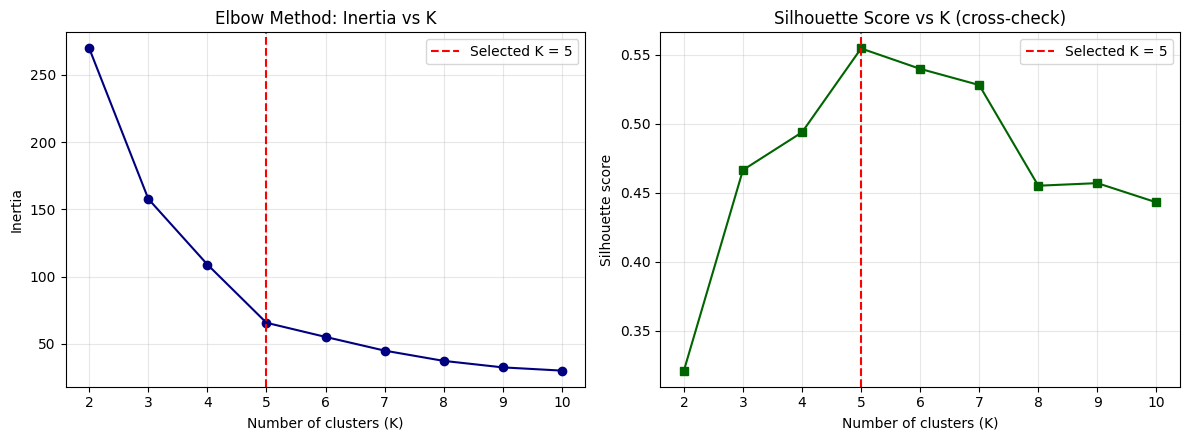

In [10]:
# Elbow plot + silhouette cross-check
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(k_results["K"], k_results["Inertia"], marker="o", color="navy")
axes[0].axvline(best_k, color="red", linestyle="--", label=f"Selected K = {best_k}")
axes[0].set_title("Elbow Method: Inertia vs K")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(k_results["K"], k_results["Silhouette"], marker="s", color="darkgreen")
axes[1].axvline(best_k, color="red", linestyle="--", label=f"Selected K = {best_k}")
axes[1].set_title("Silhouette Score vs K (cross-check)")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_elbow_and_silhouette.png", dpi=150)
plt.show()

**Why K = 5?**

- Inertia falls sharply up to K = 5 (each step from K = 2 to K = 5 cuts inertia by about 31–42%), then the improvement drops to about 16% at K = 6 and keeps shrinking. The curve bends at K = 5.
- The numerical elbow check picks the same value.
- The silhouette score is also highest at K = 5, so five clusters are the most compact and best separated.
- Together with the five visual groups in the scatter plot, K = 5 is supported by three independent pieces of evidence, not chosen arbitrarily.

## 5. Final Clustering

In [11]:
# Train the final model with the selected K
final_model = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
df["Cluster"] = final_model.fit_predict(X_scaled)

print(f"Final model: K = {best_k}, inertia = {final_model.inertia_:.2f}, "
      f"silhouette = {silhouette_score(X_scaled, df['Cluster']):.3f}")

print("\nCustomers per cluster:")
print(df["Cluster"].value_counts().sort_index())

print("\nDataframe with cluster labels:")
print(df.head(10))

Final model: K = 5, inertia = 65.57, silhouette = 0.555

Customers per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Dataframe with cluster labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   


## 6. Cluster Visualization

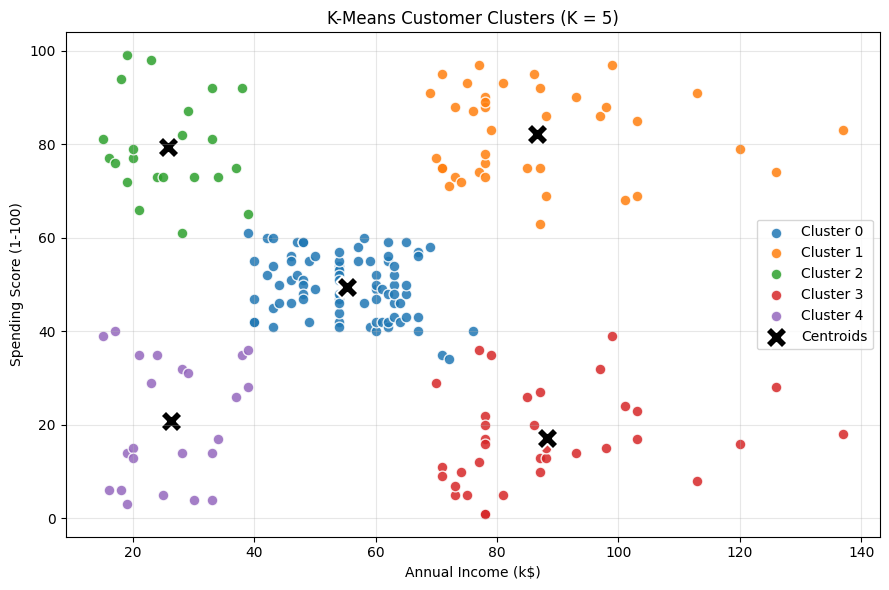

In [12]:
# Centroids were learned in scaled space, so convert them back to original units for plotting
centroids = scaler.inverse_transform(final_model.cluster_centers_)
colors = plt.cm.tab10.colors

plt.figure(figsize=(9, 6))
for c in range(best_k):
    members = df[df["Cluster"] == c]
    plt.scatter(members[INCOME], members[SCORE], s=60, color=colors[c],
                edgecolor="white", alpha=0.85, label=f"Cluster {c}")

plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c="black", marker="X",
            edgecolor="white", linewidth=1.5, label="Centroids")

plt.title(f"K-Means Customer Clusters (K = {best_k})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_kmeans_clusters.png", dpi=150)
plt.show()

## 7. Cluster Analysis

We first summarise each cluster, then name it **from its own averages**. A cluster is labelled *Low* if its mean is below the dataset's 25th percentile, *High* if it is above the 75th percentile, and *Moderate* otherwise. No names are assigned in advance.

In [13]:
# Cluster profile: size, average income, average spending score (plus age and gender for context)
summary = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Income=(INCOME, "mean"),
    Avg_Spending_Score=(SCORE, "mean"),
    Avg_Age=("Age", "mean"),
    Pct_Female=("Gender", lambda s: (s == "Female").mean() * 100),
).round(1)
summary["Pct_of_Customers"] = (summary["Customers"] / len(df) * 100).round(1)

# Name each segment based on where its averages fall relative to the whole dataset
def level(value, series):
    if value < series.quantile(0.25):
        return "Low"
    if value > series.quantile(0.75):
        return "High"
    return "Moderate"

names = {
    c: f"{level(row.Avg_Income, df[INCOME])} Income / {level(row.Avg_Spending_Score, df[SCORE])} Spending"
    for c, row in summary.iterrows()
}
assert len(set(names.values())) == len(names), "Two clusters got the same name - review the naming rule."

summary.insert(0, "Segment", pd.Series(names))
df["Segment"] = df["Cluster"].map(names)

print(summary.sort_values("Avg_Spending_Score", ascending=False).to_string())

                                     Segment  Customers  Avg_Income  Avg_Spending_Score  Avg_Age  Pct_Female  Pct_of_Customers
Cluster                                                                                                                       
1                High Income / High Spending         39        86.5                82.1     32.7        53.8              19.5
2                 Low Income / High Spending         22        25.7                79.4     25.3        59.1              11.0
0        Moderate Income / Moderate Spending         81        55.3                49.5     42.7        59.3              40.5
4                  Low Income / Low Spending         23        26.3                20.9     45.2        60.9              11.5
3                 High Income / Low Spending         35        88.2                17.1     41.1        45.7              17.5


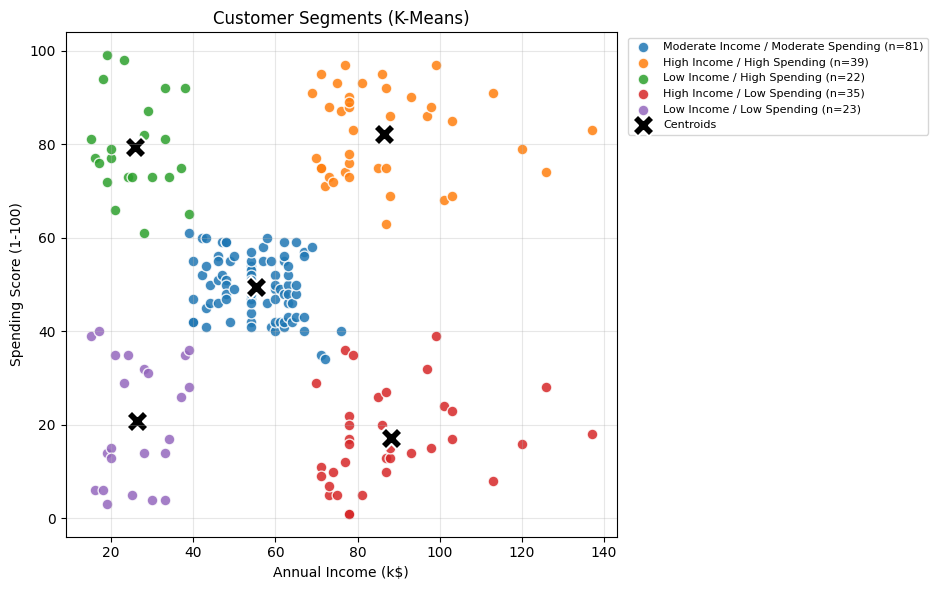

In [14]:
# Same scatter plot, now with the segment names in the legend
plt.figure(figsize=(9.5, 6))
for c in range(best_k):
    members = df[df["Cluster"] == c]
    plt.scatter(members[INCOME], members[SCORE], s=60, color=colors[c],
                edgecolor="white", alpha=0.85, label=f"{names[c]} (n={len(members)})")
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c="black", marker="X",
            edgecolor="white", linewidth=1.5, label="Centroids")

plt.title("Customer Segments (K-Means)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_named_segments.png", dpi=150, bbox_inches="tight")
plt.show()

**Segment characteristics** (from the table above)

- **High Income / High Spending:** wealthy customers who also spend a lot. This is a young group (average age in the early 30s) and the top spending-score segment.
- **Low Income / High Spending:** customers with small incomes but very high spending scores. This is the youngest segment (mid-20s on average).
- **High Income / Low Spending:** customers with a lot of purchasing power who spend very little at this mall. Their average age is around 41.
- **Low Income / Low Spending:** low income and low spending, and the oldest segment (mid-40s on average).
- **Moderate Income / Moderate Spending:** the largest segment, close to the overall average on both measures. It contains about four in ten customers (40.5%).

Every segment has a fairly balanced gender mix (roughly 46%–61% female), so gender is not a strong separator here.

## 8. Average Spending Analysis

Segment
High Income / High Spending            82.1
Low Income / High Spending             79.4
Moderate Income / Moderate Spending    49.5
Low Income / Low Spending              20.9
High Income / Low Spending             17.1
Name: Avg_Spending_Score, dtype: float64

Overall average spending score: 50.2


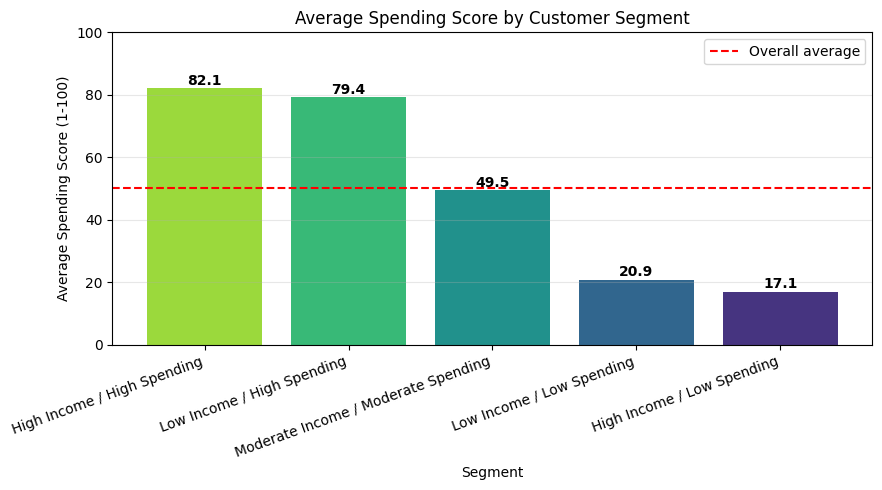

In [15]:
# Average spending score per cluster, sorted from highest to lowest
avg_spend = summary.set_index("Segment")["Avg_Spending_Score"].sort_values(ascending=False)
print(avg_spend.round(1))
print(f"\nOverall average spending score: {df[SCORE].mean():.1f}")

plt.figure(figsize=(9, 5))
bars = plt.bar(avg_spend.index, avg_spend.values, color=plt.cm.viridis(np.linspace(0.85, 0.15, len(avg_spend))))
plt.axhline(df[SCORE].mean(), color="red", linestyle="--", label="Overall average")
for bar, value in zip(bars, avg_spend.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}", ha="center", fontweight="bold")

plt.title("Average Spending Score by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Average Spending Score (1-100)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_avg_spending_by_segment.png", dpi=150)
plt.show()

**Comparison**

- **Highest spenders:** *High Income / High Spending* (about 82) and *Low Income / High Spending* (about 79) are far above the overall average of about 50. Note that the low-income group spends almost as much (in score terms) as the wealthy group, so spending behaviour is not driven by income alone.
- **Middle:** *Moderate Income / Moderate Spending* sits almost exactly on the overall average.
- **Lowest spenders:** *High Income / Low Spending* (about 17) and *Low Income / Low Spending* (about 21) are less than half the average. The high-income low spenders are notable because their low spending is a choice, not a budget limit.

## 9. Bonus: DBSCAN

DBSCAN groups points that are densely packed and labels isolated points as **noise** (`-1`). It needs no K, but it is sensitive to `eps` (neighbourhood radius in scaled units) and `min_samples` (points needed to form a dense core). We try a grid of reasonable values first.

In [16]:
# Try several eps / min_samples combinations on the scaled features
grid_rows = []
for eps in [0.25, 0.30, 0.35, 0.40, 0.50]:
    for min_samples in [3, 5, 7]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        grid_rows.append({
            "eps": eps,
            "min_samples": min_samples,
            "Clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "Noise points": int((labels == -1).sum()),
        })

print(pd.DataFrame(grid_rows).to_string(index=False))

 eps  min_samples  Clusters  Noise points
0.25            3        12            16
0.25            5         6            50
0.25            7         5            77
0.30            3         9            14
0.30            5         7            35
0.30            7         4            72
0.35            3         7            11
0.35            5         6            23
0.35            7         5            47
0.40            3         4            10
0.40            5         4            15
0.40            7         4            20
0.50            3         2             7
0.50            5         2             8
0.50            7         2            12


In [17]:
# Chosen setting: it finds a similar number of dense groups as K-Means while keeping noise limited
EPS, MIN_SAMPLES = 0.35, 5
df["DBSCAN_Cluster"] = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(X_scaled)

n_clusters = df["DBSCAN_Cluster"].nunique() - (1 if -1 in df["DBSCAN_Cluster"].values else 0)
n_noise = (df["DBSCAN_Cluster"] == -1).sum()
print(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}): {n_clusters} clusters, "
      f"{n_noise} noise points ({n_noise / len(df) * 100:.1f}%)")

print("\nDBSCAN cluster profile (-1 = noise):")
print(df.groupby("DBSCAN_Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Income=(INCOME, "mean"),
    Avg_Spending_Score=(SCORE, "mean"),
).round(1))

DBSCAN (eps=0.35, min_samples=5): 6 clusters, 23 noise points (11.5%)

DBSCAN cluster profile (-1 = noise):
                Customers  Avg_Income  Avg_Spending_Score
DBSCAN_Cluster                                           
-1                     23        89.3                57.8
 0                     16        24.8                75.4
 1                     12        24.6                 9.6
 2                      7        22.4                34.4
 3                     88        55.2                48.6
 4                     31        80.3                83.2
 5                     23        81.0                12.8


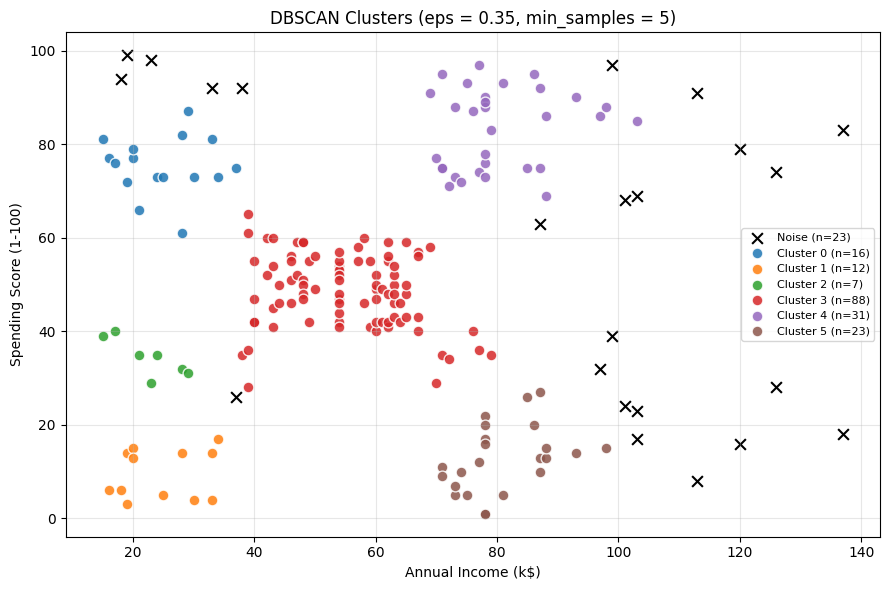

In [18]:
# Visualise DBSCAN clusters; noise points are shown as black crosses
plt.figure(figsize=(9, 6))
for label in sorted(df["DBSCAN_Cluster"].unique()):
    members = df[df["DBSCAN_Cluster"] == label]
    if label == -1:
        plt.scatter(members[INCOME], members[SCORE], color="black", marker="x", s=60,
                    label=f"Noise (n={len(members)})")
    else:
        plt.scatter(members[INCOME], members[SCORE], s=60, color=colors[label % 10],
                    edgecolor="white", alpha=0.85, label=f"Cluster {label} (n={len(members)})")

plt.title(f"DBSCAN Clusters (eps = {EPS}, min_samples = {MIN_SAMPLES})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_dbscan_clusters.png", dpi=150)
plt.show()

In [19]:
# Compare DBSCAN with K-Means
print("Cross-tab: K-Means cluster (rows) vs DBSCAN cluster (columns, -1 = noise)")
print(pd.crosstab(df["Segment"], df["DBSCAN_Cluster"]))

ari = adjusted_rand_score(df["Cluster"], df["DBSCAN_Cluster"])
print(f"\nAdjusted Rand Index between the two labelings: {ari:.3f} (1.0 = identical)")

Cross-tab: K-Means cluster (rows) vs DBSCAN cluster (columns, -1 = noise)
DBSCAN_Cluster                       -1   0   1   2   3   4   5
Segment                                                        
High Income / High Spending           8   0   0   0   0  31   0
High Income / Low Spending            9   0   0   0   3   0  23
Low Income / High Spending            5  16   0   0   1   0   0
Low Income / Low Spending             1   0  12   7   3   0   0
Moderate Income / Moderate Spending   0   0   0   0  81   0   0

Adjusted Rand Index between the two labelings: 0.790 (1.0 = identical)


**DBSCAN vs K-Means**

- **Results:** with `eps = 0.35` and `min_samples = 5`, DBSCAN finds 6 dense clusters and flags 23 customers (11.5%) as noise. The adjusted Rand index against K-Means is about 0.79, so the two methods agree on the overall structure.
- **Where they agree:** the large central group is recovered exactly (all 81 Moderate/Moderate customers land in one DBSCAN cluster), and the other three corner groups of K-Means are each found as a dense core.
- **Where they differ:**
    - DBSCAN sends 23 customers to noise, many of them in the sparse high-income area (the noise points have an average income of about 89k$), whereas K-Means must assign every customer to a cluster.
    - DBSCAN splits the *Low Income / Low Spending* group into two small dense clumps (12 and 7 customers) and puts a few border customers into the big central cluster.
    - The result is sensitive to the parameters: a smaller `eps` produces more noise and more fragments, while `eps` of 0.4–0.5 merges neighbouring groups into only 2–4 clusters (see the grid above). K-Means with K = 5 was much more stable.
- **Why they differ:** K-Means partitions all points around centroids and prefers compact, similarly sized groups, so it always returns exactly K clusters and never leaves anyone out. DBSCAN defines clusters as regions of high point density separated by sparse space, so it needs no K and can label outliers, but it uses one global density threshold. Here the central group is dense while the high-income groups are spread out, so a single `eps` cannot suit both, and points in the sparse regions are more likely to be labelled noise.
- **Takeaway:** for this dataset K-Means gives cleaner, more usable segments for marketing (everyone belongs to a segment, and the five groups are well separated). DBSCAN is a useful second opinion that confirms the structure and highlights unusual or borderline customers.

## 10. Final Business Insights

**Methodology summary**

- Loaded and checked the 200-customer dataset (no missing values, no duplicates); clustered on Annual Income and Spending Score after standardising them with `StandardScaler`; kept the two high-income points that the IQR rule flagged because they are real customers.
- Ran K-Means for K = 2 to 10, chose **K = 5** using the elbow method (confirmed numerically and by the silhouette score, 0.555), then profiled and named each cluster from its own averages.
- Compared with DBSCAN (`eps = 0.35`, `min_samples = 5`), which found a similar structure (ARI about 0.79) plus 23 noise points.

**Main findings**

- **Five meaningful segments** were identified:

| Segment | Customers | Avg income (k$) | Avg spending score |
|---|---|---|---|
| High Income / High Spending | 39 (19.5%) | 86.5 | 82.1 |
| Low Income / High Spending | 22 (11.0%) | 25.7 | 79.4 |
| Moderate Income / Moderate Spending | 81 (40.5%) | 55.3 | 49.5 |
| Low Income / Low Spending | 23 (11.5%) | 26.3 | 20.9 |
| High Income / Low Spending | 35 (17.5%) | 88.2 | 17.1 |

- **High spending behaviour:** *High Income / High Spending* and *Low Income / High Spending* (together about 30% of customers).
- **Potential high-value customers:** *High Income / High Spending* is the clear core, since it combines purchasing power with high spending. *High Income / Low Spending* is the biggest **untapped opportunity**: 17.5% of customers with the highest average income but the lowest spending score.
- **Low spending behaviour:** *High Income / Low Spending* and *Low Income / Low Spending*.
- Income alone does not predict spending: two segments with very similar low or high incomes behave in opposite ways.

**How a retailer could use the segments**

| Segment | Suggested approach |
|---|---|
| High Income / High Spending | Retention first: VIP or tiered loyalty programme, early access to new collections, personalised service. |
| High Income / Low Spending | Find out why they spend so little here (survey, browsing and purchase data), then test premium ranges, personalised offers and exclusive events to raise their share of wallet. |
| Low Income / High Spending | Value-focused loyalty: points, bundles, student or youth deals and instalment options; protect margins because these customers are budget-limited. |
| Moderate Income / Moderate Spending | Largest group, so small gains matter: seasonal promotions, cross-sell and loyalty-tier incentives that encourage a step up to the high-spending group. |
| Low Income / Low Spending | Low-cost engagement only (email or app coupons); avoid heavy promotional spend. |

**Limitations:** the dataset is small (200 customers), uses only two behavioural features and shows a *spending score* rather than actual revenue, so segment value should be confirmed with real sales data, and campaign ideas should be tested (for example with A/B tests) before rollout.

In [20]:
# Save the dataset with cluster labels for further use
df.to_csv("Mall_Customers_clustered.csv", index=False)
print("Saved: Mall_Customers_clustered.csv")

Saved: Mall_Customers_clustered.csv
